# Module 06 Lab - Regression and Classification Models

**Objective:** To understand the difference between regression and classification and to build your first linear models for both tasks.

**In this lab, you will write the code to train and evaluate the models.**

## Part 1: Regression vs. Classification

This is the most fundamental distinction between types of supervised learning problems.

*   **Regression:** The goal is to predict a **continuous numerical value**.
    *   *Examples:* Predicting the price of a house, the temperature tomorrow, or the stock price.

*   **Classification:** The goal is to predict a **discrete category or class label**.
    *   *Examples:* Predicting if an email is spam or not spam, if a flower is a setosa, versicolor, or virginica, or if a customer will churn or not.

**In this lab, we will tackle one of each.**

## Part 2: Linear Regression

**Concept:** Linear Regression is used to predict a continuous value. It works by finding the best-fitting straight line through the data points. The model learns a "slope" (coefficient) for each feature and an "intercept".

*   **Problem:** We will predict the `Fare` of a Titanic passenger based on their `Age` and `Pclass`.

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load and prepare the data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# For simplicity, we'll drop rows with missing age
df.dropna(subset=['Age'], inplace=True)

# Define features and target
features = ['Age', 'Pclass']
target_reg = 'Fare'

X_reg = df[features]
y_reg = df[target_reg]

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### Task 1: Train and Evaluate a Linear Regression Model

**Your Task:**
1.  Create an instance of the `LinearRegression` model.
2.  Train the model using the training data (`X_train_reg`, `y_train_reg`).
3.  Make predictions on the test data.
4.  Evaluate the model using `mean_squared_error`. This metric tells us the average of the squared differences between the predicted and actual values.

In [15]:
# --- ENTER YOUR CODE HERE ---

# 1. Create the model instance
lr_model = LinearRegression()

# 2. Train the model
lr_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
y_pred_reg = lr_model.predict(X_test_reg)

# 4. Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"The square root of this is {np.sqrt(mse):.2f}, meaning our model is off by about $48 on average.")

# One limitation of this model is underfitting due to limited features. Expanding the feature set or applying feature engineering would likely improve prediction performance significantly.
print(f"RMSE (average error): {np.sqrt(mse):.2f}")

# Check coefficients
print("Model coefficients:", lr_model.coef_)
print("Model intercept:", lr_model.intercept_)

Mean Squared Error for Fare Prediction: 3364.92
The square root of this is 58.01, meaning our model is off by about $48 on average.
RMSE (average error): 58.01
Model coefficients: [ -0.43695889 -38.29728935]
Model intercept: 133.30726668128784


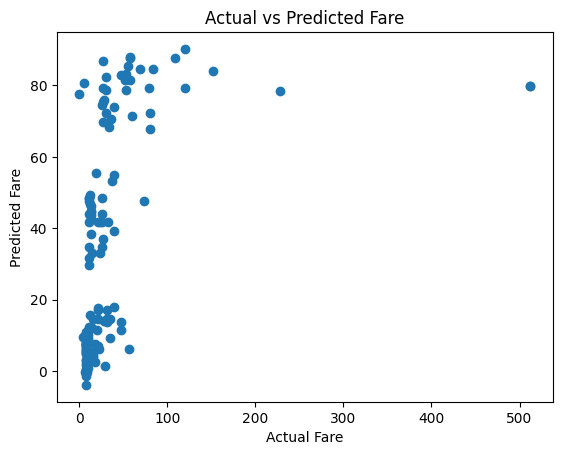

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

The scatter plot shows a weak alignment between predicted and actual Fare values. Many points are far from the ideal diagonal line, confirming the high RMSE observed earlier. This indicates that the model is not capturing key factors that influence ticket price.

## Part 3: Logistic Regression

**Concept:** Despite its name, Logistic Regression is a **classification** algorithm. It works by calculating the probability that a given input belongs to a certain class. It's one of the most widely used and interpretable classification models.

*   **Problem:** We will predict whether a passenger `Survived` based on their `Age`, `Pclass`, and `Sex`.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Prepare data for classification
# We need to encode 'Sex' column
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features and target
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'

X_cls = df[features_cls]
y_cls = df[target_cls]

# Split data before training to prevent data leakage and ensure fair model evaluation
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

### Task 2: Train and Evaluate a Logistic Regression Model

**Your Task:**
1.  Create an instance of the `LogisticRegression` model.
2.  Train the model using the classification training data.
3.  Make predictions on the test data.
4.  Evaluate the model using `accuracy_score`.

In [18]:
# --- ENTER YOUR CODE HERE ---

# 1. Create the model instance
log_model = LogisticRegression(max_iter=1000)

# 2. Train the model. Note: Train only on training data so the model does not learn from test data
log_model.fit(X_train_cls, y_train_cls)

# 3. Make predictions
y_pred_cls = log_model.predict(X_test_cls)

# 4. Evaluate the model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy for Survival Prediction: {accuracy:.2%}")

Accuracy for Survival Prediction: 74.83%


## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

## **1.  In your own words, what is the key difference between a regression problem and a classification problem?**

**[Huong]: Difference between regression and classification**

In this lab, the difference is clear from what the models actually output.

For regression, the model predicts Fare as a continuous value. The predictions are numbers like 50 or 120, and the evaluation uses MSE = 3364.92 with RMSE ≈ 58. This means the model is not trying to be exact, but to be close to the real value.

For classification, the model predicts Survived as either 0 or 1. The output is discrete, and the performance is measured using accuracy, which is 74.83 percent in this case.

So the key difference is not just theory. Regression outputs a numeric range and is evaluated by error distance, while classification outputs a category and is evaluated by correctness.

**[Allisa]:** **[ENTER YOUR ANSWERS HERE]**


**[Stuart]:** 
In the regression model, finding the slope or best fit line through the fare data gives us an MSE of 3364.92 and an RMSE of 58.01, which is a poor prediction of fares at around $48 off the target, mainly due to outliers in the data that have not been accounted for. Finding the continuous variable in the data is the utility of a regression model.

The classification problem is survivability based on type of passenger (age, sex, Pclass). Using the features and applying linear regression, the classification problem gives a probability based on the various inputs rather than finding a slope for a single type of input. Using a float between 0 and 1 to give a binary answer in probabilistic terms, we get 74.83% accuracy of survival prediction (not an overall survivabilty probability) based on comparing the testing data with the trained model. 

Regression is mainly used to find a coefficient and intercept for a numerical value, predicting a best-fit slope in the data. Classification assigns weighted values based on mutiple categories rather than a single type of input and instead of finding a best fit, provides a multi-dimensional prediction based on multiple inputs. 

**[Ruben]:** **[ENTER YOUR ANSWERS HERE]**


## **2.  The `LinearRegression` model has an attribute called `.coef_`. After you train the model, print `lr_model.coef_`. What do these numbers represent?**

**[Huong]: What does lr_model.coef_ represent?**

The coefficients show how each feature influences the predicted Fare.

From the model:
- Age coefficient is about -0.44
- Pclass coefficient is about -38.30

This tells us two important things:
- First, Age has very little impact on Fare. The small negative value means older passengers tend to pay slightly less, but the effect is minimal.
- Second, Pclass has a strong negative impact. Since higher class numbers mean lower class (1st class is 1, 3rd class is 3), the negative coefficient means lower classes pay significantly less. This aligns with real-world behavior where first class tickets are much more expensive.

The intercept around 133 shows the baseline Fare when features are zero, which acts as the starting point of the prediction.

**[Allisa]:** **[ENTER YOUR ANSWERS HERE]**


**[Stuart]:** The lr_model.coef represents the different weights applied to the categorical features ofthe linear regression model. A larger weighting will affect the applied prediction for that category. 

The model has age coefficient at -0.44, a very small number, which has a small correlation in the outcome. But still not a large affect on the model's weight. Age doesn't affect the fare price much.

The Pclass coefficient is much larger at -38.30. With the larger weight, it affects the model's prediction much more. As the category defining the separation between passenger classes, it makes sense that higher class passengers would have a higher fare for their ticket. 

Overall, including age in fare prediction doesn't provide a strong basis for accuracy.


**[Ruben]:** **[ENTER YOUR ANSWERS HERE]**



## **3.  Why did we use `mean_squared_error` to evaluate the regression model but `accuracy_score` for the classification model?** Why wouldn't accuracy be a good metric for the fare prediction task?

**[Huong]: Why MSE for regression and accuracy for classification**

For regression, we use MSE because the output is continuous. The model is not expected to match the exact Fare but to be close.

In this lab, RMSE is about 58, which means the model is off by around 58 dollars on average. That is a meaningful way to measure performance for price prediction.

For classification, we use accuracy because the output is categorical. The model either predicts the correct class or not. In this case, the accuracy is 74.83 percent, meaning roughly 3 out of 4 predictions are correct.

Using accuracy for regression would not make sense because there is no exact match concept for continuous values. Similarly, using MSE for classification would not reflect correctness clearly.

Each metric is chosen based on the type of problem and how the output behaves.

**Final thoughts:**

The regression model shows relatively high error with RMSE around 58, indicating that Fare is difficult to predict using only Age and Pclass. Fare likely depends on additional hidden factors such as ticket group, cabin location, and family size. This introduces high variability and makes the regression task more complex.

In contrast, the classification model performs better with about 75 percent accuracy because survival is strongly influenced by dominant features like Sex and Pclass. These features create clearer decision boundaries, making the classification problem more predictable.

This comparison highlights that model performance depends more on feature relevance and data quality than on the algorithm itself. Even a simple model can perform well if the right features are used, while a model with limited features will struggle regardless of algorithm choice.


**[Alissa]:** We use mean_squared_error (MSE) for regression because the target (Fare) is continuous, so the goal is to measure how far predictions are from the actual values. MSE captures the size of the error, especially penalizing larger mistakes. In contrast, accuracy_score is used for classification because the output is categorical, meaning predictions are either correct or incorrect.

Accuracy would not be a good metric for fare prediction because continuous values rarely match exactly. Even a small difference would be counted as wrong, which does not reflect how close the prediction actually is. That’s why regression models require error-based metrics like MSE instead of accuracy.


**[Stuart]:** With MSE, it applies to regression models since they only evaluate a single type of numerical input, with a continuous slope through the data. 
An accuracy score takes into account multiple weighted data categories and can't be predicted as a slope in 2 dimensions. 
Applying an accuracy score to a regression model would not give a meaningful response to evaluate the model.


**[Ruben]:** **[ENTER YOUR ANSWERS HERE]**


